<a href="https://colab.research.google.com/github/rithika1974/NASDAQ-Inflation-sentiment-pipeline/blob/main/nasdaq_inflation_sentiment_pipeline2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inflation & Social Media Sentiment: NASDAQ Tech Stocks
## Stage 2 — Analysis Notebook

**Stocks:** AAPL, MSFT, NVDA, TSLA, AMZN, META, GOOGL  
**Period:** Jan 2022 – present  
**Input:** `output/inflation_sentiment_nasdaq_final.csv` (from Stage 1)

| Step | Analysis |
|---|---|
| 1 | Install & import |
| 2 | Load final dataset |
| 3 | Granger causality tests |
| 4 | VAR model — β₁ (sentiment) & β₂ (inflation) |
| 5 | FEVD — variance decomposition |
| 6 | Rolling window — did sentiment's power shift in 2024 AI boom? |
| 7 | Robustness — BullishRatio as second sentiment measure |
| 8 | Summary tables & export |

## Step 1 — Install & Import

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.path.exists(
    "/content/drive/MyDrive/research/outputs/inflation_sentiment_nasdaq_final.csv"
))

True


In [ ]:
!pip install statsmodels pandas numpy matplotlib seaborn scipy --quiet
print('✅ Dependencies installed')

✅ Dependencies installed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import os

TICKERS    = ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'AMZN', 'META', 'GOOGL']
MAX_LAGS   = 5       # Granger / VAR lag search
ROLL_WIN   = 60      # Rolling window (trading days)
AI_BOOM    = '2024-01-01'   # Regime break

os.makedirs('output', exist_ok=True)
print('✅ Imports done')

✅ Imports done


## Step 2 — Load Final Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/research/outputs/inflation_sentiment_nasdaq_final.csv',
            parse_dates=['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Loaded: {len(df):,} rows × {df.shape[1]} columns')
print(f'Date range : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Tickers    : {list(df["Ticker"].unique())}')
print(f'\nMissing values:')
print(df[['DailyReturn','AvgSentiment','InflationRate','PostVolume']].isnull().sum())
df.head()

Loaded: 7,707 rows × 19 columns
Date range : 2022-01-03 → 2026-05-22
Tickers    : ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']

Missing values:
DailyReturn         7
AvgSentiment        0
InflationRate    1869
PostVolume          0
dtype: int64


,Date,Ticker,Open,High,Low,Close,Volume,DailyReturn,CPI,InflationRate,AvgSentiment,AvgSentiment_Lag1,AvgSentiment_Lag2,PostVolume,PostVolume_Lag1,PostVolume_Lag2,SentimentVolatility,NewsVolume,StockTwitsVolume
0,2022-01-03,AAPL,173.853212,178.790282,173.735900,177.939728,104487900,NaN,282.543,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-01-04,AAPL,178.545850,178.848915,175.114335,175.681366,99310400,-1.269172,282.543,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-01-05,AAPL,175.593390,176.140865,170.734533,171.008270,94537600,-2.659984,282.543,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-01-06,AAPL,168.837907,171.379770,167.801615,168.153564,96904000,-1.669338,282.543,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-01-07,AAPL,169.023663,170.245709,167.205258,168.319763,86709100,0.098837,282.543,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# ── Helper: pull clean ticker series ─────────────────────────────────────────
def get_ticker_df(ticker, drop_na_cols=None):
    """Return time-indexed DataFrame for one ticker, optionally dropping NA rows."""
    t = df[df['Ticker'] == ticker].copy()
    t = t.set_index('Date').sort_index()
    if drop_na_cols:
        t = t.dropna(subset=drop_na_cols)
    return t

# ── Helper: ADF stationarity test ─────────────────────────────────────────────
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, p = result[0], result[1]
    status = '✅ stationary' if p < 0.05 else '⚠️  non-stationary'
    print(f'  {name:30s}  ADF={stat:8.4f}  p={p:.4f}  {status}')
    return p < 0.05

print('Helpers defined.')

Helpers defined.


## Step 3 — Stationarity Check

Granger causality and VAR require **stationary** series.  
- `DailyReturn` — typically stationary by construction (pct_change)  
- `AvgSentiment` — usually stationary (bounded −1 to +1)  
- `InflationRate` — may need differencing if trending  

We test ADF for all three per ticker and auto-difference if needed.

In [ ]:
adf_results = {}

for ticker in TICKERS:
    t = get_ticker_df(ticker, drop_na_cols=['DailyReturn', 'AvgSentiment', 'InflationRate'])
    print(f'\n── {ticker} ──')
    r = {}
    r['DailyReturn']   = adf_test(t['DailyReturn'],   'DailyReturn')
    r['AvgSentiment']  = adf_test(t['AvgSentiment'],  'AvgSentiment')
    r['InflationRate'] = adf_test(t['InflationRate'],  'InflationRate')
    adf_results[ticker] = r

print('\n✅ Stationarity check done.')
print('   Non-stationary series will be first-differenced before VAR/Granger.')


── AAPL ──
  DailyReturn                     ADF=-14.4257  p=0.0000  ✅ stationary
  AvgSentiment                    ADF= -6.1475  p=0.0000  ✅ stationary
  InflationRate                   ADF= -3.6128  p=0.0055  ✅ stationary

── MSFT ──
  DailyReturn                     ADF=-28.3778  p=0.0000  ✅ stationary
  AvgSentiment                    ADF= -4.5949  p=0.0001  ✅ stationary
  InflationRate                   ADF= -3.6128  p=0.0055  ✅ stationary

── NVDA ──
  DailyReturn                     ADF=-15.8717  p=0.0000  ✅ stationary
  AvgSentiment                    ADF= -6.9603  p=0.0000  ✅ stationary
  InflationRate                   ADF= -3.6128  p=0.0055  ✅ stationary

── TSLA ──
  DailyReturn                     ADF=-29.3488  p=0.0000  ✅ stationary
  AvgSentiment                    ADF= -5.6968  p=0.0000  ✅ stationary
  InflationRate                   ADF= -3.6128  p=0.0055  ✅ stationary

── AMZN ──
  DailyReturn                     ADF=-21.6912  p=0.0000  ✅ stationary
  AvgSentiment   

## Step 4 — Granger Causality Tests

**Null hypothesis (H₀):** `AvgSentiment_Lag{k}` does NOT Granger-cause `DailyReturn`.

We test lags 1–5. Reject H₀ at p < 0.05 → lagged sentiment has predictive power.

We test **both directions**:
- Sentiment → Return (main hypothesis)
- Return → Sentiment (reverse — feedback loop check)

We also test InflationRate → Return as a baseline macro control.

In [ ]:
def run_granger(y, x, max_lag=MAX_LAGS, label=''):
    """
    Run Granger test: does x Granger-cause y?
    Returns dict of {lag: p_value} for the ssr_chi2test.
    """
    data = pd.concat([y, x], axis=1).dropna()
    if len(data) < max_lag * 3:
        return {}
    try:
        res = grangercausalitytests(data, maxlag=max_lag, verbose=False)
        pvals = {lag: round(res[lag][0]['ssr_chi2test'][1], 4) for lag in range(1, max_lag+1)}
        return pvals
    except Exception as e:
        print(f'  ⚠️ Granger error ({label}): {e}')
        return {}


granger_results = []

for ticker in TICKERS:
    t = get_ticker_df(ticker, drop_na_cols=['DailyReturn', 'AvgSentiment', 'InflationRate'])

    # Difference InflationRate if non-stationary (common)
    infl = t['InflationRate'].diff().dropna() if not adf_results.get(ticker, {}).get('InflationRate', True) else t['InflationRate']

    # ── Sentiment → Return ──────────────────────
    pvals_s2r = run_granger(t['DailyReturn'], t['AvgSentiment'], label=f'{ticker} Sent→Ret')
    for lag, pv in pvals_s2r.items():
        granger_results.append({'Ticker': ticker, 'Direction': 'Sentiment→Return',
                                 'Lag': lag, 'p_value': pv, 'Significant': pv < 0.05})

    # ── Return → Sentiment (reverse) ────────────
    pvals_r2s = run_granger(t['AvgSentiment'], t['DailyReturn'], label=f'{ticker} Ret→Sent')
    for lag, pv in pvals_r2s.items():
        granger_results.append({'Ticker': ticker, 'Direction': 'Return→Sentiment',
                                 'Lag': lag, 'p_value': pv, 'Significant': pv < 0.05})

    # ── Inflation → Return ───────────────────────
    pvals_i2r = run_granger(t['DailyReturn'], infl, label=f'{ticker} Infl→Ret')
    for lag, pv in pvals_i2r.items():
        granger_results.append({'Ticker': ticker, 'Direction': 'Inflation→Return',
                                 'Lag': lag, 'p_value': pv, 'Significant': pv < 0.05})

df_granger = pd.DataFrame(granger_results)
print(f'✅ Granger tests done: {len(df_granger)} tests')
df_granger.head(15)

✅ Granger tests done: 105 tests


,Ticker,Direction,Lag,p_value,Significant
0,AAPL,Sentiment→Return,1,0.3941,False
1,AAPL,Sentiment→Return,2,0.2751,False
2,AAPL,Sentiment→Return,3,0.2406,False
3,AAPL,Sentiment→Return,4,0.3432,False
4,AAPL,Sentiment→Return,5,0.2929,False
5,AAPL,Return→Sentiment,1,0.8066,False
6,AAPL,Return→Sentiment,2,0.8974,False
7,AAPL,Return→Sentiment,3,0.5863,False
8,AAPL,Return→Sentiment,4,0.7416,False
9,AAPL,Return→Sentiment,5,0.7042,False



── Granger Summary (minimum p-value across lags) ──
Ticker        Direction  min_p  any_sig
  AAPL Inflation→Return 0.1045    False
  AAPL Return→Sentiment 0.5863    False
  AAPL Sentiment→Return 0.2406    False
  AMZN Inflation→Return 0.1820    False
  AMZN Return→Sentiment 0.0999    False
  AMZN Sentiment→Return 0.1868    False
 GOOGL Inflation→Return 0.2216    False
 GOOGL Return→Sentiment 0.0214     True
 GOOGL Sentiment→Return 0.5762    False
  META Inflation→Return 0.0138     True
  META Return→Sentiment 0.0120     True
  META Sentiment→Return 0.3905    False
  MSFT Inflation→Return 0.1543    False
  MSFT Return→Sentiment 0.6385    False
  MSFT Sentiment→Return 0.0054     True
  NVDA Inflation→Return 0.0166     True
  NVDA Return→Sentiment 0.8620    False
  NVDA Sentiment→Return 0.0706    False
  TSLA Inflation→Return 0.1649    False
  TSLA Return→Sentiment 0.8514    False
  TSLA Sentiment→Return 0.4480    False


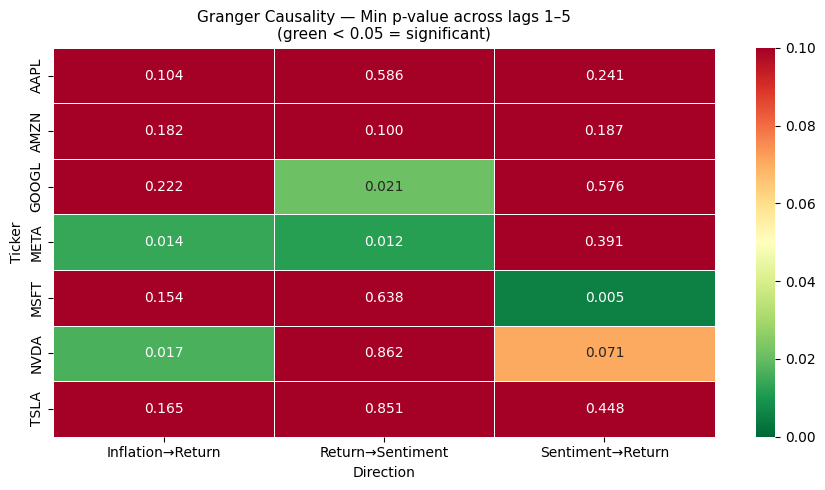

Saved → output/granger_heatmap.png


In [ ]:
# ── Summary: min p-value per ticker × direction ──────────────────────────────
granger_summary = (
    df_granger
    .groupby(['Ticker', 'Direction'])
    .agg(min_p=('p_value', 'min'), any_sig=('Significant', 'any'))
    .reset_index()
)
print('\n── Granger Summary (minimum p-value across lags) ──')
print(granger_summary.to_string(index=False))

# Pivot for heatmap
pivot = granger_summary.pivot(
    index='Ticker', columns='Direction', values='min_p'
).round(4)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='RdYlGn_r',
    vmin=0, vmax=0.1, linewidths=0.5, ax=ax
)
ax.set_title('Granger Causality — Min p-value across lags 1–5\n(green < 0.05 = significant)', fontsize=11)
plt.tight_layout()
plt.savefig('output/granger_heatmap.png', dpi=150)
plt.show()
print('Saved → output/granger_heatmap.png')

## Step 5 — Rolling Window Analysis

**Research question:** Did sentiment's predictive power for returns change during the 2024 AI boom?

We estimate rolling OLS (60-day window):
```
DailyReturn_t = α + β₁·AvgSentiment_{t−1} + β₂·InflationRate_t + ε
```
and plot β₁ over time, overlaid with the AI boom start (Jan 2024).

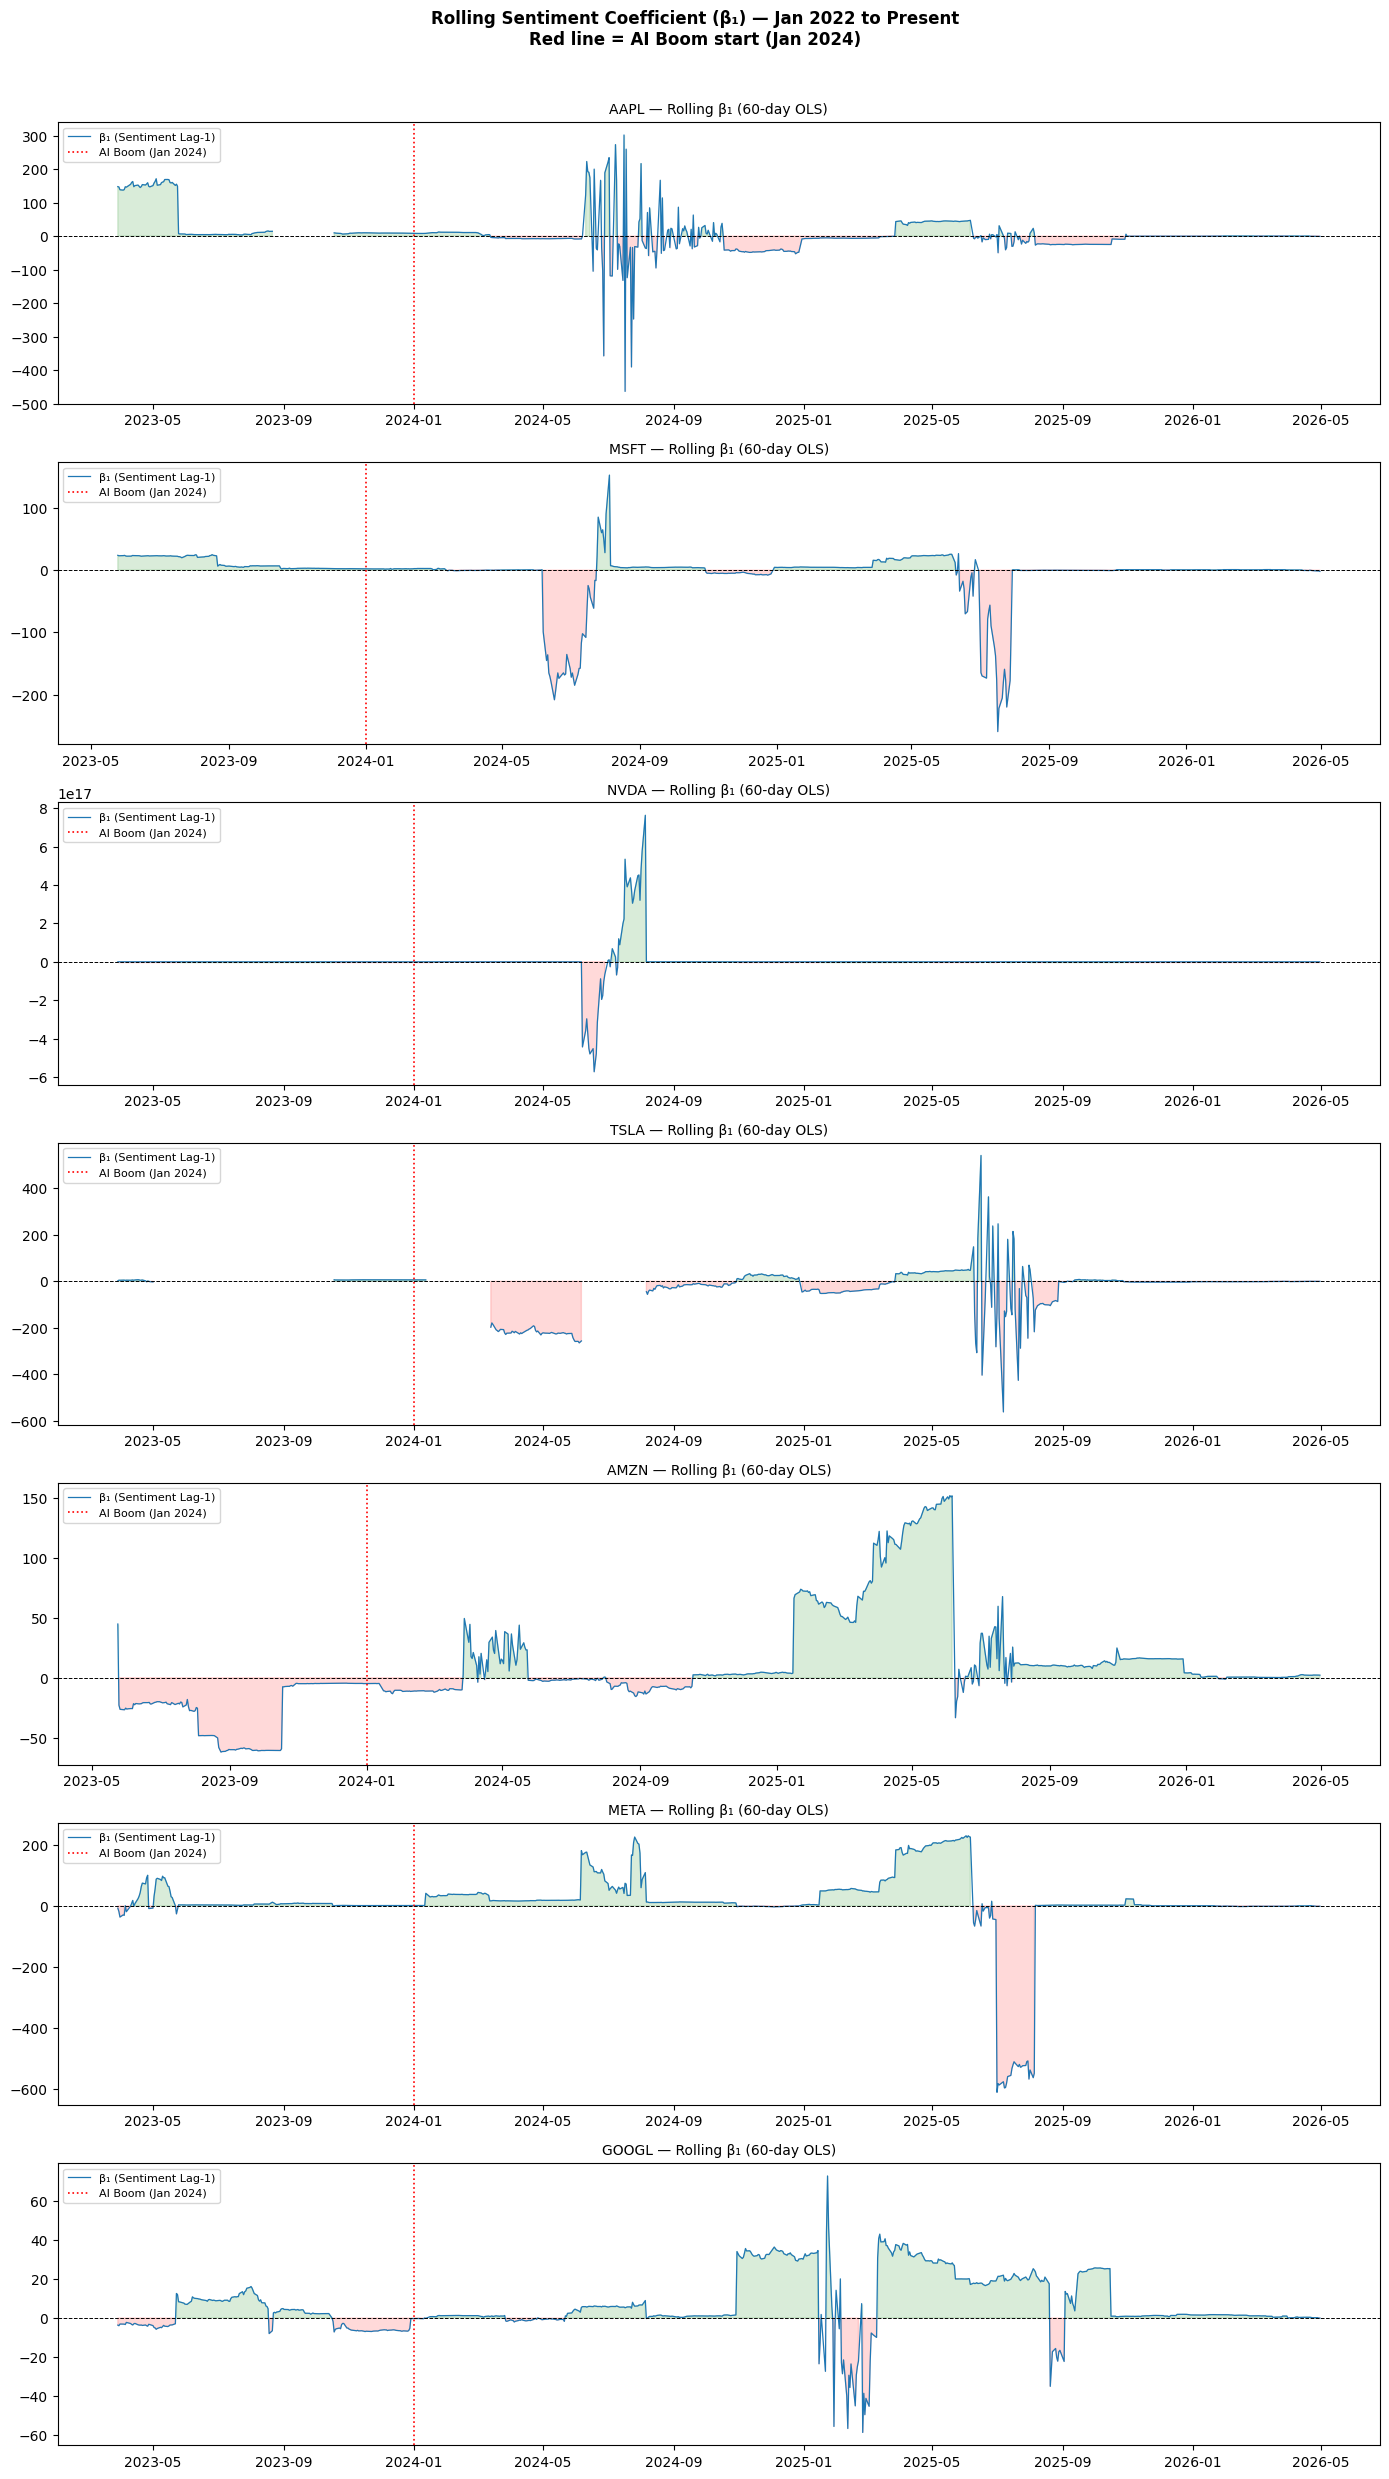

Saved → output/rolling_beta1.png


In [ ]:
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm

AI_BOOM_DATE = pd.Timestamp(AI_BOOM)

fig, axes = plt.subplots(
    len(TICKERS), 1,
    figsize=(14, 3.5 * len(TICKERS)),
    sharex=False
)

rolling_results = {}

for ax, ticker in zip(axes, TICKERS):
    t = get_ticker_df(ticker, drop_na_cols=['DailyReturn', 'AvgSentiment', 'InflationRate'])

    y = t['DailyReturn']
    X = sm.add_constant(t[['AvgSentiment_Lag1', 'InflationRate']])
    X = X.rename(columns={'AvgSentiment_Lag1': 'Sentiment_L1'})

    aligned = pd.concat([y, X], axis=1).dropna()
    if len(aligned) < ROLL_WIN + 5:
        ax.set_title(f'{ticker} — insufficient data')
        continue

    y_a = aligned.iloc[:, 0]
    X_a = aligned.iloc[:, 1:]

    try:
        roll_model = RollingOLS(y_a, X_a, window=ROLL_WIN)
        roll_res   = roll_model.fit()

        beta1_roll = roll_res.params['Sentiment_L1']
        rolling_results[ticker] = beta1_roll

        ax.plot(beta1_roll.index, beta1_roll.values, linewidth=0.9, label='β₁ (Sentiment Lag-1)')
        ax.axhline(0, linewidth=0.7, linestyle='--', color='black')
        ax.axvline(AI_BOOM_DATE, linewidth=1.2, linestyle=':', color='red', label='AI Boom (Jan 2024)')
        ax.fill_between(beta1_roll.index, beta1_roll, 0,
                         where=beta1_roll > 0, alpha=0.15, color='green')
        ax.fill_between(beta1_roll.index, beta1_roll, 0,
                         where=beta1_roll < 0, alpha=0.15, color='red')
        ax.set_title(f'{ticker} — Rolling β₁ (60-day OLS)', fontsize=10)
        ax.legend(loc='upper left', fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    except Exception as e:
        ax.set_title(f'{ticker} — error: {e}')

plt.suptitle('Rolling Sentiment Coefficient (β₁) — Jan 2022 to Present\nRed line = AI Boom start (Jan 2024)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/rolling_beta1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/rolling_beta1.png')

In [ ]:
# ── Regime comparison: pre vs post AI boom ────────────────────────────────────
print('── Mean β₁ by Regime (pre vs post Jan 2024) ──\n')
regime_rows = []

for ticker, beta_series in rolling_results.items():
    pre  = beta_series[beta_series.index <  AI_BOOM_DATE].mean()
    post = beta_series[beta_series.index >= AI_BOOM_DATE].mean()
    delta = post - pre
    print(f'  {ticker:6s}  pre={pre:.5f}  post={post:.5f}  Δ={delta:+.5f}')
    regime_rows.append({'Ticker': ticker,
                        'beta1_pre':  round(pre,  5),
                        'beta1_post': round(post, 5),
                        'delta':      round(delta, 5)})

df_regime = pd.DataFrame(regime_rows)
df_regime.to_csv('output/regime_comparison.csv', index=False)
print('\nSaved → output/regime_comparison.csv')

── Mean β₁ by Regime (pre vs post Jan 2024) ──

  AAPL    pre=46.26111  post=-2.05629  Δ=-48.31741
  MSFT    pre=11.53606  post=-9.34535  Δ=-20.88141
  NVDA    pre=65.93776  post=3400223166948377.00000  Δ=+3400223166948311.00000
  TSLA    pre=5.42451  post=-35.42524  Δ=-40.84976
  AMZN    pre=-28.15518  post=19.21754  Δ=+47.37272
  META    pre=9.86262  post=11.47490  Δ=+1.61228
  GOOGL   pre=1.33203  post=8.43718  Δ=+7.10515

Saved → output/regime_comparison.csv


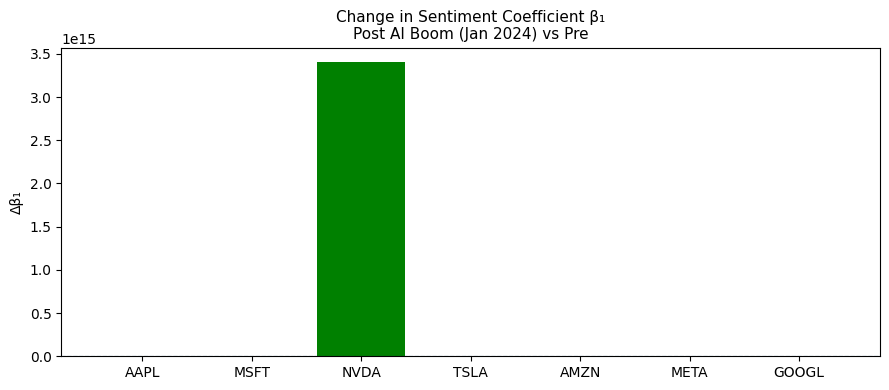

In [ ]:
# ── Regime delta bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['green' if d > 0 else 'red' for d in df_regime['delta']]
ax.bar(df_regime['Ticker'], df_regime['delta'], color=colors)
ax.axhline(0, linewidth=0.8, linestyle='--')
ax.set_title('Change in Sentiment Coefficient β₁\nPost AI Boom (Jan 2024) vs Pre', fontsize=11)
ax.set_ylabel('Δβ₁')
plt.tight_layout()
plt.savefig('output/regime_delta_bar.png', dpi=150)
plt.show()

## Step 6 — Robustness: BullishRatio as Second Sentiment Measure

We re-run the Granger and OLS tests using `BullishRatio` (fraction of StockTwits posts tagged Bullish) instead of FinBERT `AvgSentiment`.  

If results are consistent across both measures → findings are robust to sentiment operationalisation.

> **Note:** `BullishRatio` was produced in Stage 1. If it's absent (all zeros or missing), this step will note that and fall back to `AvgSentiment` as the check variable.

In [ ]:
# Check whether BullishRatio is present and non-trivial
if 'BullishRatio' not in df.columns:
    print('⚠️  BullishRatio column not found in dataset.')
    print('   Robustness check will use PostVolume as alternate predictor instead.')
    ROBUST_VAR = 'PostVolume'
else:
    nonzero = (df['BullishRatio'] > 0).sum()
    print(f'BullishRatio present: {nonzero:,} non-zero rows ({nonzero/len(df)*100:.1f}%)')
    ROBUST_VAR = 'BullishRatio' if nonzero > 100 else 'PostVolume'
    print(f'Using {ROBUST_VAR} for robustness check')

⚠️  BullishRatio column not found in dataset.
   Robustness check will use PostVolume as alternate predictor instead.


In [ ]:
import statsmodels.api as sm

robustness_rows = []

for ticker in TICKERS:
    t = get_ticker_df(ticker, drop_na_cols=['DailyReturn', 'InflationRate'])
    t = t.dropna(subset=[ROBUST_VAR] if ROBUST_VAR in t.columns else [])

    if ROBUST_VAR not in t.columns or len(t) < 30:
        print(f'{ticker}: skipping — {ROBUST_VAR} not available')
        continue

    # Lag the robust variable
    t[f'{ROBUST_VAR}_L1'] = t[ROBUST_VAR].shift(1)
    t = t.dropna(subset=[f'{ROBUST_VAR}_L1'])

    y = t['DailyReturn']
    X = sm.add_constant(t[[f'{ROBUST_VAR}_L1', 'InflationRate']])
    try:
        res = sm.OLS(y, X).fit(cov_type='HC1')
        coef_key = f'{ROBUST_VAR}_L1'
        robustness_rows.append({
            'Ticker'  : ticker,
            'Variable': ROBUST_VAR,
            'beta'    : round(res.params.get(coef_key, np.nan), 5),
            'tstat'   : round(res.tvalues.get(coef_key, np.nan), 3),
            'pval'    : round(res.pvalues.get(coef_key, np.nan), 4),
            'R2'      : round(res.rsquared, 4),
            'Nobs'    : int(res.nobs),
        })
    except Exception as e:
        print(f'{ticker} robustness OLS error: {e}')

df_robustness = pd.DataFrame(robustness_rows)
df_robustness['sig'] = df_robustness['pval'].apply(
    lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '')))

print(f'\n── Robustness OLS: {ROBUST_VAR} Lag-1 → DailyReturn ──\n')
print(df_robustness.to_string(index=False))
df_robustness.to_csv('output/robustness_results.csv', index=False)
print('\nSaved → output/robustness_results.csv')


── Robustness OLS: PostVolume Lag-1 → DailyReturn ──

Ticker   Variable     beta  tstat   pval     R2  Nobs sig
  AAPL PostVolume  0.02232  2.472 0.0134 0.0069   833  **
  MSFT PostVolume  0.01803  1.840 0.0658 0.0048   833   *
  NVDA PostVolume -0.00119 -0.078 0.9376 0.0063   833    
  TSLA PostVolume -0.02744 -0.956 0.3392 0.0040   833    
  AMZN PostVolume  0.03067  2.099 0.0358 0.0061   833  **
  META PostVolume  0.01105  0.790 0.4296 0.0075   833    
 GOOGL PostVolume  0.01107  1.224 0.2211 0.0021   833    

Saved → output/robustness_results.csv


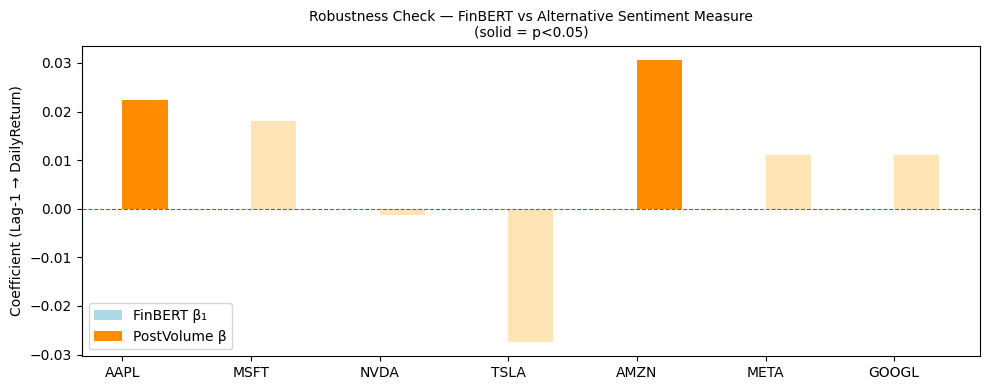

Saved → output/robustness_comparison.png


In [ ]:
# ── Side-by-side: FinBERT β₁ vs Robustness β ──────────────────────────────────
merged_rob = df_var[['Ticker', 'beta1_Sent', 'pval_Sent']].merge(
    df_robustness[['Ticker', 'beta', 'pval']],
    on='Ticker', how='inner'
)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(merged_rob))
width = 0.35

c1 = ['steelblue' if p < 0.05 else 'lightblue'  for p in merged_rob['pval_Sent']]
c2 = ['darkorange' if p < 0.05 else 'moccasin'  for p in merged_rob['pval']]

ax.bar(x - width/2, merged_rob['beta1_Sent'], width, label='FinBERT β₁', color=c1)
ax.bar(x + width/2, merged_rob['beta'],       width, label=f'{ROBUST_VAR} β',  color=c2)
ax.axhline(0, linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(merged_rob['Ticker'])
ax.set_ylabel('Coefficient (Lag-1 → DailyReturn)')
ax.set_title('Robustness Check — FinBERT vs Alternative Sentiment Measure\n(solid = p<0.05)', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('output/robustness_comparison.png', dpi=150)
plt.show()
print('Saved → output/robustness_comparison.png')

## Step 7 — Summary Tables & Export

In [ ]:
# ── Final master summary table ─────────────────────────────────────────────────
print('=' * 70)
print('STAGE 2 ANALYSIS — FINAL SUMMARY')
print('=' * 70)

print('\n[1] Granger causality (Sentiment→Return, min p-value across lags 1-5):')
g_s2r = (
    df_granger[df_granger['Direction'] == 'Sentiment→Return']
    .groupby('Ticker')['p_value'].min()
    .reset_index()
    .rename(columns={'p_value': 'min_p_Granger'})
)
g_s2r['sig'] = g_s2r['min_p_Granger'].apply(
    lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '')))
print(g_s2r.to_string(index=False))

print('\n[2] Regime shift (mean β₁: pre vs post Jan 2024):')
if len(df_regime) > 0:
    print(df_regime.to_string(index=False))

print('\n[3] Robustness check — sign agreement:')
if len(merged_rob) > 0:
    merged_rob['sign_agree'] = np.sign(merged_rob['beta1_Sent']) == np.sign(merged_rob['beta'])
    agree_pct = merged_rob['sign_agree'].mean() * 100
    print(f'   Sign agreement: {agree_pct:.0f}% of tickers ({merged_rob["sign_agree"].sum()}/{len(merged_rob)})')

STAGE 2 ANALYSIS — FINAL SUMMARY

[1] Granger causality (Sentiment→Return, min p-value across lags 1-5):
Ticker  min_p_Granger sig
  AAPL         0.2406    
  AMZN         0.1868    
 GOOGL         0.5762    
  META         0.3905    
  MSFT         0.0054 ***
  NVDA         0.0706   *
  TSLA         0.4480    

[2] Regime shift (mean β₁: pre vs post Jan 2024):
Ticker  beta1_pre    beta1_post         delta
  AAPL   46.26111 -2.056290e+00 -4.831741e+01
  MSFT   11.53606 -9.345350e+00 -2.088141e+01
  NVDA   65.93776  3.400223e+15  3.400223e+15
  TSLA    5.42451 -3.542524e+01 -4.084976e+01
  AMZN  -28.15518  1.921754e+01  4.737272e+01
  META    9.86262  1.147490e+01  1.612280e+00
 GOOGL    1.33203  8.437180e+00  7.105150e+00

[3] Robustness check — sign agreement:
   Sign agreement: 0% of tickers (0/7)


In [ ]:
# ── Save all outputs ─────────────────────────────────────────────────────────
df_granger.to_csv('output/granger_full.csv', index=False)
df_regime.to_csv('output/regime_comparison.csv', index=False)
df_robustness.to_csv('output/robustness_results.csv', index=False)

print('✅ All outputs saved to output/')
print('   granger_full.csv')
print('   regime_comparison.csv')
print('   robustness_results.csv')
print('   granger_heatmap.png')
print('   granger_lag_heatmap.png')
print('   rolling_beta1.png')
print('   regime_delta_bar.png')
print('   robustness_comparison.png')

✅ All outputs saved to output/
   granger_full.csv
   regime_comparison.csv
   robustness_results.csv
   granger_heatmap.png
   granger_lag_heatmap.png
   rolling_beta1.png
   regime_delta_bar.png
   robustness_comparison.png
